### Imports and Configuration


In [1]:
# Import shared libraries, metrics, and utilities used by all later stages of this notebook.
# Keep metric definitions centralized so split evaluation and cross-validation are computed consistently.
# Configure warnings once to keep long experiment output readable during repeated runs.

import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, fbeta_score, roc_auc_score,
                              average_precision_score)
from sklearn.model_selection import StratifiedKFold, cross_validate


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Paths and Data Loading


In [3]:
from pathlib import Path

# Build project-relative paths to keep the notebook portable across environments and machines.
# Load the prepared UNSW train/validation/test splits so every model is benchmarked on identical partitions.
# Ensure output directories exist before training so artifact persistence does not fail at the end.

# Determine BASE_DIR using a robust search strategy
cwd = Path('/content/drive/MyDrive/MLmodeling/XAI')
if (cwd / 'models').exists() and (cwd / 'features').exists():
    BASE_DIR = cwd
elif (cwd.parent / 'models').exists() and (cwd.parent / 'features').exists():
    BASE_DIR = cwd.parent
elif len(cwd.parents) > 1 and (cwd.parents[1] / 'models').exists() and (cwd.parents[1] / 'features').exists():
    BASE_DIR = cwd.parents[1]
else:
    # Fallback to the default expected location if the project structure isn't immediately found
    # This might need adjustment if your project is structured differently.
    BASE_DIR = Path('/content/drive/MyDrive/MLmodeling/XAI')

SPLITS_DIR = BASE_DIR / "splits" / "UNSW-NB15"
MODEL_DIR  = BASE_DIR / "models" / "UNSW-NB15"
RESULT_DIR = BASE_DIR / "results" / "UNSW-NB15"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# sklearn artifacts in models/UNSW-NB15/*.pkl were trained on the first 188 OHE columns.
# Current X_*.csv may list 192 columns (4 extra trailing state_* one-hots).
UNSW_MODEL_N_FEATURES = 188

def _unsw_X_csv_to_values(path):
    df = pd.read_csv(path)
    n = df.shape[1]
    if n > UNSW_MODEL_N_FEATURES:
        df = df.iloc[:, :UNSW_MODEL_N_FEATURES]
    elif n < UNSW_MODEL_N_FEATURES:
        raise ValueError(
            f"{path.name}: need >= {UNSW_MODEL_N_FEATURES} columns to match saved models, got {n}"
        )
    return df.values

X_train = _unsw_X_csv_to_values(SPLITS_DIR / "X_train.csv")
X_val   = _unsw_X_csv_to_values(SPLITS_DIR / "X_val.csv")
X_test  = _unsw_X_csv_to_values(SPLITS_DIR / "X_test.csv")

y_train = pd.read_csv(SPLITS_DIR / "y_train.csv").squeeze()
y_val   = pd.read_csv(SPLITS_DIR / "y_val.csv").squeeze()
y_test  = pd.read_csv(SPLITS_DIR / "y_test.csv").squeeze()

print(f"Train : {X_train.shape} | Attack ratio: {y_train.mean():.2%}")
print(f"Val   : {X_val.shape}   | Attack ratio: {y_val.mean():.2%}")
print(f"Test  : {X_test.shape}  | Attack ratio: {y_test.mean():.2%}")

Train : (180371, 188) | Attack ratio: 63.91%
Val   : (38651, 188)   | Attack ratio: 63.91%
Test  : (38651, 188)  | Attack ratio: 63.91%


### Model Definition


In [4]:
# Define MLP with explicit hyperparameters so this experiment remains easy to reproduce and compare.
# Keep model initialization isolated from training/evaluation so tuning changes stay localized to one place.
# `random_state=42` is set to reduce run-to-run variance and keep benchmark comparisons fair.

from sklearn.neural_network import MLPClassifier
ARTIFACT_NAME = "UNSW_13_MLP"
MODEL_NAME = "MLP"
model = MLPClassifier(max_iter=300, random_state=42)


### Train and Evaluate


In [5]:
# Fit the model and evaluate train/validation/test in one flow to quickly reveal overfitting or underfitting.
# Report threshold metrics (accuracy, precision, recall, F1, F2) and ranking metrics (ROC-AUC, PR-AUC) together.
# PR-AUC is especially informative for imbalanced attack detection, so it complements ROC-AUC in this setting.

model.fit(X_train, y_train)

def evaluate(model, X, y, split_name):
    y_pred = model.predict(X)
    y_prob = (model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba")
              else model.decision_function(X) if hasattr(model, "decision_function")
              else None)
    return {
        "split":     split_name,
        "accuracy":  round(accuracy_score(y, y_pred), 6),
        "precision": round(precision_score(y, y_pred, zero_division=0), 6),
        "recall":    round(recall_score(y, y_pred, zero_division=0), 6),
        "f1":        round(f1_score(y, y_pred, zero_division=0), 6),
        "f2":        round(fbeta_score(y, y_pred, beta=2, zero_division=0), 6),
        "roc_auc":   round(roc_auc_score(y, y_prob), 6) if y_prob is not None else None,
        "pr_auc":    round(average_precision_score(y, y_prob), 6) if y_prob is not None else None,
    }

train_m = evaluate(model, X_train, y_train, "train")
val_m   = evaluate(model, X_val,   y_val,   "val")
test_m  = evaluate(model, X_test,  y_test,  "test")

train_test_gap = round(train_m['f1'] - test_m['f1'], 6)
train_val_gap  = round(train_m['f1'] - val_m['f1'],  6)

print(f"Train    F1: {train_m['f1']:.4f} | ROC-AUC: {train_m['roc_auc']}")
print(f"Val      F1: {val_m['f1']:.4f}   | ROC-AUC: {val_m['roc_auc']}")
print(f"Test     F1: {test_m['f1']:.4f}  | ROC-AUC: {test_m['roc_auc']}")


Train    F1: 0.9527 | ROC-AUC: 0.989272
Val      F1: 0.9497   | ROC-AUC: 0.988074
Test     F1: 0.9537  | ROC-AUC: 0.9891


### Cross-Validation (5-Fold Stratified)


In [6]:
# Use stratified 5-fold cross-validation to estimate generalization more reliably than a single split.
# Fold-level train/validation metrics expose variance and train-vs-validation gap across folds.
# Parallelism is enabled for speed here; reduce to `n_jobs=1` only when memory pressure becomes an issue.

# Use n_jobs=1 for MLP and KNN to avoid memory errors
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv  = cross_validate(model, X_train, y_train, cv=skf,
                     scoring=['f1', 'roc_auc', 'average_precision'],
                     return_train_score=True,
                     n_jobs=-1)

fold_results = pd.DataFrame({
    "fold":        list(range(1, 6)),
    "train_f1":    cv['train_f1'],
    "val_f1":      cv['test_f1'],
    "val_roc_auc": cv['test_roc_auc'],
    "val_pr_auc":  cv['test_average_precision'],
    "cv_gap":      cv['train_f1'] - cv['test_f1'],
})
print("Per-fold results:")
print(fold_results.to_string(index=False))

cv_results = {
    "cv_train_f1_mean": round(cv['train_f1'].mean(), 6),
    "cv_val_f1_mean":   round(cv['test_f1'].mean(),  6),
    "cv_val_f1_std":    round(cv['test_f1'].std(),   6),
    "cv_val_roc_mean":  round(cv['test_roc_auc'].mean(), 6),
    "cv_val_pr_mean":   round(cv['test_average_precision'].mean(), 6),
    "cv_gap":           round((cv['train_f1'] - cv['test_f1']).mean(), 6),
}

print(f"\nCV Summary:")
print(f"  Train F1 mean : {cv_results['cv_train_f1_mean']:.4f}")
print(f"  Val   F1 mean : {cv_results['cv_val_f1_mean']:.4f} Ã‚Â± {cv_results['cv_val_f1_std']:.4f}")
print(f"  Val ROC-AUC   : {cv_results['cv_val_roc_mean']:.4f}")
print(f"  CV Gap        : {cv_results['cv_gap']:.4f}")

fold_results['model']   = MODEL_NAME
fold_results['dataset'] = "UNSW-NB15"
fold_results.to_csv(RESULT_DIR / f"{ARTIFACT_NAME}_cv_folds.csv", index=False)
print(f"\nPer-fold results saved.")


Per-fold results:
 fold  train_f1   val_f1  val_roc_auc  val_pr_auc   cv_gap
    1  0.952772 0.949862     0.988150    0.993515 0.002909
    2  0.953532 0.952279     0.989008    0.993992 0.001254
    3  0.954797 0.950409     0.988099    0.993196 0.004389
    4  0.952761 0.950804     0.988438    0.993640 0.001957
    5  0.951936 0.950107     0.988150    0.993501 0.001829

CV Summary:
  Train F1 mean : 0.9532
  Val   F1 mean : 0.9507 Ã‚Â± 0.0009
  Val ROC-AUC   : 0.9884
  CV Gap        : 0.0025

Per-fold results saved.


### Save Results and Model Artifact


In [7]:
# Assemble a standardized result row so this notebook aligns with the shared results schema.
# Save this notebook's latest metrics snapshot to CSV (default `to_csv` behavior overwrites the file on rerun).
# Persist the trained model artifact for downstream interpretability and analysis workflows such as SHAP and LIME.

row = {
    "dataset":         "UNSW-NB15",
    "model":           MODEL_NAME,
    "split":           "70/15/15",
    "test_accuracy":   test_m['accuracy'],
    "test_precision":  test_m['precision'],
    "test_recall":     test_m['recall'],
    "test_f1":         test_m['f1'],
    "test_f2":         test_m['f2'],
    "test_roc_auc":    test_m['roc_auc'],
    "test_pr_auc":     test_m['pr_auc'],
    "val_f1":          val_m['f1'],
    "val_f2":          val_m['f2'],
    "val_roc_auc":     val_m['roc_auc'],
    "val_pr_auc":      val_m['pr_auc'],
    "train_f1":        train_m['f1'],
    "cv_val_f1_mean":  cv_results['cv_val_f1_mean'],
    "cv_val_f1_std":   cv_results['cv_val_f1_std'],
    "cv_val_roc_mean": cv_results['cv_val_roc_mean'],
    "cv_val_pr_mean":  cv_results['cv_val_pr_mean'],
    "cv_gap":          cv_results['cv_gap'],
    "train_test_gap":  train_test_gap,
}

pd.DataFrame([row]).to_csv(RESULT_DIR / f"{ARTIFACT_NAME}.csv", index=False)
joblib.dump(model, MODEL_DIR / f"{ARTIFACT_NAME}.pkl")
print(f"{ARTIFACT_NAME}   saved.")
print(pd.DataFrame([row]).T.to_string(header=False))


UNSW_13_MLP   saved.
dataset          UNSW-NB15
model                  MLP
split             70/15/15
test_accuracy     0.941114
test_precision    0.958008
test_recall       0.949476
test_f1           0.953723
test_f2            0.95117
test_roc_auc        0.9891
test_pr_auc       0.993912
val_f1             0.94971
val_f2             0.94616
val_roc_auc       0.988074
val_pr_auc        0.993264
train_f1          0.952688
cv_val_f1_mean    0.950692
cv_val_f1_std     0.000853
cv_val_roc_mean   0.988369
cv_val_pr_mean    0.993569
cv_gap            0.002467
train_test_gap   -0.001035


## Interactive Inference (Widgets)
Use the saved UNSW-NB15 MLP artifact to run single-row predictions as **NORMAL** or **ATTACK**.

In [8]:
# Widget inference setup: load model + feature defaults + optional preprocessing artifacts.
import json
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output



cwd = Path('/content/drive/MyDrive/MLmodeling/XAI')

if (cwd / 'models').exists() and (cwd / 'features').exists():
    BASE_DIR = cwd
elif (cwd.parent / 'models').exists() and (cwd.parent / 'features').exists():
    BASE_DIR = cwd.parent
elif len(cwd.parents) > 1 and (cwd.parents[1] / 'models').exists() and (cwd.parents[1] / 'features').exists():
    BASE_DIR = cwd.parents[1]
else:
    BASE_DIR = cwd

FEATURES_FILE = BASE_DIR / 'features' / 'UNSW-NB15_features.json'
MODEL_FILE = BASE_DIR / 'models' / 'UNSW-NB15' / 'UNSW_13_MLP.pkl'
SPLIT_DIR = BASE_DIR / 'splits' / 'UNSW-NB15'

assert FEATURES_FILE.exists(), f'Feature defaults not found: {FEATURES_FILE}'
assert MODEL_FILE.exists(), f'Model file not found: {MODEL_FILE}'

with open(FEATURES_FILE, 'r', encoding='utf-8') as f:
    UNSW_DEFAULTS = json.load(f)

# Exclude non-predictive/raw label columns if present in defaults
EXCLUDE_COLS = {'id', 'attack_cat', 'label'}
UNSW_DEFAULTS = {k: v for k, v in UNSW_DEFAULTS.items() if k not in EXCLUDE_COLS}

INFER_MODEL = joblib.load(MODEL_FILE)

INFER_PREPROCESSOR = None
for pp_name in ('preprocessor.joblib', 'preprocessor.pkl'):
    pp_path = SPLIT_DIR / pp_name
    if pp_path.exists():
        INFER_PREPROCESSOR = joblib.load(pp_path)
        break

INFER_FEATURE_NAMES = None
fn_path = SPLIT_DIR / 'feature_names.csv'
if fn_path.exists():
    INFER_FEATURE_NAMES = pd.read_csv(fn_path, header=None).squeeze().tolist()
    # Match saved models: first 188 OHE names only (CSV may list 192).
    _unsw_n = 188
    if len(INFER_FEATURE_NAMES) > _unsw_n:
        INFER_FEATURE_NAMES = list(INFER_FEATURE_NAMES[:_unsw_n])

print(f'Loaded model: {MODEL_FILE.name}')
print(f'Feature defaults: {len(UNSW_DEFAULTS)}')
print(f'Preprocessor loaded: {INFER_PREPROCESSOR is not None}')


Loaded model: UNSW_13_MLP.pkl
Feature defaults: 42
Preprocessor loaded: True


In [9]:
# Build interactive UNSW form and predict NORMAL/ATTACK.
if 'UNSW_DEFAULTS' not in globals():
    print('Run the previous widget setup cell first.')
else:
    # Clear prior output area from this cell on rerun.
    clear_output(wait=True)

    # If this cell is rerun, close the previous UI instance to avoid duplicate panels.
    _ui_key = f"_UNSW_INFER_UI_{globals().get('ARTIFACT_NAME', 'UNSW')}"
    _prev_ui = globals().get(_ui_key, None)
    if _prev_ui is not None:
        try:
            _prev_ui.close()
        except Exception:
            pass

    input_widgets = {}

    def make_widget(default):
        if isinstance(default, str):
            return widgets.Text(value=str(default), layout=widgets.Layout(width='360px', min_width='300px', height='34px'))
        if isinstance(default, int) and not isinstance(default, bool):
            return widgets.IntText(value=int(default), layout=widgets.Layout(width='360px', min_width='300px', height='34px'))
        return widgets.FloatText(value=float(default), step=0.01, layout=widgets.Layout(width='360px', min_width='300px', height='34px'))

    def to_group_name(col_name):
        if '.' in col_name:
            return col_name.split('.', 1)[0]
        if '_' in col_name:
            return col_name.split('_', 1)[0]
        return 'other'

    feature_groups = {}
    for col, default in UNSW_DEFAULTS.items():
        w = make_widget(default)
        input_widgets[col] = w
        group = to_group_name(col)
        feature_groups.setdefault(group, []).append(col)

    sorted_groups = sorted(feature_groups.keys())
    group_boxes = []

    for group in sorted_groups:
        rows = []
        for col in feature_groups[group]:
            label = widgets.HTML(
                value=f'<div style="font-family:monospace; font-size:13px;">{col}</div>',
                layout=widgets.Layout(width='430px', min_width='360px')
            )
            rows.append(
                widgets.HBox(
                    [label, input_widgets[col]],
                    layout=widgets.Layout(justify_content='space-between', width='100%')
                )
            )

        group_box = widgets.VBox(rows, layout=widgets.Layout(gap='8px', padding='8px 4px'))
        group_boxes.append(group_box)

    accordion = widgets.Accordion(
        children=group_boxes,
        layout=widgets.Layout(width='100%', max_height='560px', overflow_y='auto')
    )

    for i, group in enumerate(sorted_groups):
        accordion.set_title(i, f'{group} ({len(feature_groups[group])})')

    if sorted_groups:
        accordion.selected_index = 0

    group_selector = widgets.Dropdown(
        options=[(f'{g} ({len(feature_groups[g])})', i) for i, g in enumerate(sorted_groups)],
        description='Jump to:',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='360px')
    )

    search_box = widgets.Text(
        value='',
        placeholder='Type feature name (e.g., sbytes, dttl) then press Enter',
        description='Find:',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='620px')
    )

    predict_btn = widgets.Button(
        description='Predict',
        button_style='success',
        icon='check',
        layout=widgets.Layout(width='130px', height='36px')
    )
    reset_btn = widgets.Button(
        description='Reset',
        icon='refresh',
        layout=widgets.Layout(width='110px', height='36px')
    )

    # Single-render result surface: overwrite HTML value instead of stacking Output displays.
    result_html = widgets.HTML(value='')

    _busy_key = f"_UNSW_INFER_BUSY_{globals().get('ARTIFACT_NAME', 'UNSW')}"
    _last_click_key = f"_UNSW_INFER_LAST_CLICK_{globals().get('ARTIFACT_NAME', 'UNSW')}"
    globals()[_busy_key] = False
    globals()[_last_click_key] = 0.0

    def _set_result_message(msg, color='#444'):
        result_html.value = (
            f"<div style='border:1px solid #ddd; border-radius:8px; padding:10px; max-width:700px; color:{color};'>"
            f"{msg}"
            f"</div>"
        )

    def on_group_change(change):
        if change['name'] == 'value':
            accordion.selected_index = change['new']

    def on_find_submit(_):
        q = search_box.value.strip().lower()
        if not q:
            return
        for idx, group in enumerate(sorted_groups):
            for col in feature_groups[group]:
                if q in col.lower():
                    accordion.selected_index = idx
                    _set_result_message(f'Found in group: {group}. Scroll to locate "{col}".')
                    return
        _set_result_message(f'No feature matched "{q}".', color='#b71c1c')

    def _build_input_row():
        row = {}
        for c, d in UNSW_DEFAULTS.items():
            v = input_widgets[c].value
            if isinstance(d, str):
                row[c] = str(v)
            elif isinstance(d, int) and not isinstance(d, bool):
                row[c] = int(v)
            else:
                row[c] = float(v)
        return row

    def _prepare_X(df_input):
        X_proc = None
        if INFER_PREPROCESSOR is not None:
            X_proc = INFER_PREPROCESSOR.transform(df_input)

        if X_proc is None:
            expected_n = getattr(INFER_MODEL, 'n_features_in_', None)
            if INFER_FEATURE_NAMES is not None and (expected_n is None or len(INFER_FEATURE_NAMES) == int(expected_n)):
                X_proc = df_input.reindex(columns=[str(c) for c in INFER_FEATURE_NAMES], fill_value=0).astype(float).values
            elif hasattr(INFER_MODEL, 'feature_names_in_'):
                model_cols = [str(c) for c in INFER_MODEL.feature_names_in_]
                X_proc = df_input.reindex(columns=model_cols, fill_value=0).astype(float).values
            else:
                X_proc = df_input.select_dtypes(include=[np.number]).values

        expected_n = getattr(INFER_MODEL, 'n_features_in_', None)
        if expected_n is not None and X_proc.shape[1] != int(expected_n):
            if X_proc.shape[1] > int(expected_n):
                X_proc = np.asarray(X_proc)[:, :int(expected_n)]
            else:
                raise ValueError(f'Feature mismatch: expected {int(expected_n)}, got {X_proc.shape[1]}')

        if hasattr(INFER_MODEL, 'feature_names_in_') and X_proc.shape[1] == len(INFER_MODEL.feature_names_in_):
            return pd.DataFrame(X_proc, columns=[str(c) for c in INFER_MODEL.feature_names_in_])
        return X_proc

    def on_predict(_):
        import time as _time

        now = _time.perf_counter()
        last = float(globals().get(_last_click_key, 0.0))
        # Ignore duplicate click events arriving within a short window.
        if now - last < 0.25:
            return
        globals()[_last_click_key] = now

        if globals().get(_busy_key, False):
            return

        globals()[_busy_key] = True
        predict_btn.disabled = True
        try:
            row = _build_input_row()
            df_input = pd.DataFrame([row])
            X_input = _prepare_X(df_input)

            # Due to potential scikit-learn version incompatibility (observed warnings),
            # the loaded LogisticRegression model might be missing expected attributes.
            # Specifically, 'multi_class' is sometimes implicitly accessed by older versions
            # of scikit-learn when processing models saved by newer versions.
            # This is a heuristic fix to allow execution to proceed, assuming a binary classification.
            if not hasattr(INFER_MODEL, 'multi_class'):
                # For binary classification, 'ovr' is typically the default strategy.
                # This patch attempts to satisfy the attribute lookup.
                INFER_MODEL.multi_class = 'ovr'

            pred = int(INFER_MODEL.predict(X_input)[0])
            label = 'ATTACK' if pred == 1 else 'NORMAL'
            color = '#d32f2f' if pred == 1 else '#388e3c'

            score_html = ''
            if hasattr(INFER_MODEL, 'predict_proba'):
                p = INFER_MODEL.predict_proba(X_input)[0]
                normal_score = float(p[0])
                attack_score = float(p[1])
                pred_score = attack_score if pred == 1 else normal_score
                score_html = (
                    f"<div style='margin-top:8px;font-size:14px;color:#444;'>"
                    f"normal_score={normal_score:.4f} | attack_score={attack_score:.4f} | "
                    f"prediction_confidence={pred_score:.4f}</div>"
                )
            elif hasattr(INFER_MODEL, 'decision_function'):
                decision_score = float(np.ravel(INFER_MODEL.decision_function(X_input))[0])
                score_html = f"<div style='margin-top:8px;font-size:14px;color:#444;'>decision_score={decision_score:.6f}</div>"

            _model_label = globals().get('MODEL_NAME', 'Model')
            result_html.value = f"""
                <div style='border:2px solid {color}; border-radius:8px; padding:14px; max-width:700px;'>
                    <div style='font-size:22px; font-weight:700; color:{color};'>Prediction: {label}</div>
                    <div style='margin-top:6px; font-size:13px; color:#666;'>Dataset: UNSW-NB15 | Model: {_model_label}</div>
                    {score_html}
                </div>
            """
        except Exception as e:
            _set_result_message(f'Prediction failed: {e}', color='#b71c1c')
        finally:
            predict_btn.disabled = False
            globals()[_busy_key] = False

    def on_reset(_):
        for c, d in UNSW_DEFAULTS.items():
            input_widgets[c].value = d
        _set_result_message('Inputs reset to UNSW feature defaults.')

    def _bind_single_click(btn, handler):
        # Defensive rebinding: prevent duplicate callbacks on the same button object.
        try:
            btn._click_handlers.callbacks.clear()
        except Exception:
            pass
        btn.on_click(handler)

    group_selector.observe(on_group_change, names='value')
    try:
        search_box._submission_callbacks.callbacks.clear()
    except Exception:
        pass
    search_box.on_submit(on_find_submit)
    _bind_single_click(predict_btn, on_predict)
    _bind_single_click(reset_btn, on_reset)

    controls = widgets.HBox(
        [group_selector, predict_btn, reset_btn],
        layout=widgets.Layout(gap='10px', align_items='center')
    )

    _unsw_infer_ui = widgets.VBox([
        widgets.HTML('<h3 style="margin:0;">UNSW-NB15 Interactive Inference</h3>'),
        widgets.HTML('<div style="color:#555;">Edit values below and click Predict to classify as NORMAL or ATTACK.</div>'),
        search_box,
        controls,
        accordion,
        result_html
    ], layout=widgets.Layout(gap='10px', width='100%'))
    display(_unsw_infer_ui)
    globals()[_ui_key] = _unsw_infer_ui

## Cell 8: XAI Analysis (SHAP + LIME + Rule Diagrams)

This section mirrors the structured explainability workflow with global/local SHAP, rule-style analysis, stability/fidelity metrics, and LIME visuals.


In [10]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 15.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=3f7040973596e430a02eb0124c92b789050d327e03138db5907c9bd26f15f131
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [11]:
# STEP 1: XAI imports + readiness checks (standalone-friendly)
import sys
import subprocess
import time
from pathlib import Path

try:
    import shap
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap'])
    import shap

try:
    import lime
    import lime.lime_tabular
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lime'])
    import lime
    import lime.lime_tabular

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# If training variables are not present, load from saved artifacts/splits.
required = ['model', 'X_train', 'X_test', 'y_test']
missing = [k for k in required if k not in globals()]
if missing:
    cwd = Path('/content/drive/MyDrive/MLmodeling/XAI')
    if (cwd / 'models').exists() and (cwd / 'splits').exists():
        BASE_DIR = cwd
    elif (cwd.parent / 'models').exists() and (cwd.parent / 'splits').exists():
        BASE_DIR = cwd.parent
    elif len(cwd.parents) > 1 and (cwd.parents[1] / 'models').exists() and (cwd.parents[1] / 'splits').exists():
        BASE_DIR = cwd.parents[1]
    else:
        BASE_DIR = cwd

    SPLITS_DIR = BASE_DIR / 'splits' / 'UNSW-NB15'
    MODEL_DIR = BASE_DIR / 'models' / 'UNSW-NB15'

    if 'X_train' not in globals():
        npy_train = SPLITS_DIR / 'X_train_proc.npy'
        csv_train = SPLITS_DIR / 'X_train.csv'
        if npy_train.exists():
            X_train = np.load(npy_train)
        elif csv_train.exists():
            _unsw_n = int(globals().get('UNSW_MODEL_N_FEATURES', 188))
            _df = pd.read_csv(csv_train)
            if _df.shape[1] > _unsw_n:
                _df = _df.iloc[:, :_unsw_n]
            elif _df.shape[1] < _unsw_n:
                raise ValueError(
                    f"{csv_train.name}: need >= {_unsw_n} columns for saved UNSW models, got {_df.shape[1]}"
                )
            X_train = _df.values
        else:
            raise FileNotFoundError(f'Could not find X_train in {SPLITS_DIR}')

    if 'X_test' not in globals():
        npy_test = SPLITS_DIR / 'X_test_proc.npy'
        csv_test = SPLITS_DIR / 'X_test.csv'
        if npy_test.exists():
            X_test = np.load(npy_test)
        elif csv_test.exists():
            _unsw_n = int(globals().get('UNSW_MODEL_N_FEATURES', 188))
            _df = pd.read_csv(csv_test)
            if _df.shape[1] > _unsw_n:
                _df = _df.iloc[:, :_unsw_n]
            elif _df.shape[1] < _unsw_n:
                raise ValueError(
                    f"{csv_test.name}: need >= {_unsw_n} columns for saved UNSW models, got {_df.shape[1]}"
                )
            X_test = _df.values
        else:
            raise FileNotFoundError(f'Could not find X_test in {SPLITS_DIR}')

    if 'y_test' not in globals():
        y_test_file = SPLITS_DIR / 'y_test.csv'
        if y_test_file.exists():
            y_test = pd.read_csv(y_test_file).squeeze()
        else:
            raise FileNotFoundError(f'Could not find y_test.csv in {SPLITS_DIR}')

    if 'model' not in globals():
        model_file = MODEL_DIR / 'UNSW_13_MLP.pkl'
        if not model_file.exists():
            raise FileNotFoundError(f'Model artifact missing: {model_file}')
        model = joblib.load(model_file)

    if 'MODEL_NAME' not in globals():
        MODEL_NAME = 'MLP'

    if 'ARTIFACT_NAME' not in globals():
        ARTIFACT_NAME = 'UNSW_13_MLP'

    if 'RESULT_DIR' not in globals():
        RESULT_DIR = BASE_DIR / 'results' / 'UNSW-NB15'
        RESULT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style('whitegrid')
np.random.seed(42)
print('XAI dependencies/data ready.')
print(f'X_train: {np.shape(X_train)} | X_test: {np.shape(X_test)} | y_test: {len(y_test)}')


XAI dependencies/data ready.
X_train: (180371, 188) | X_test: (38651, 188) | y_test: 38651


PermutationExplainer explainer: 301it [01:43,  2.91it/s]


Top SHAP features:
         feature  mean_abs_shap
            dttl       0.155774
            swin       0.117310
    ct_state_ttl       0.089850
  ct_dst_src_ltm       0.078715
            sttl       0.059675
     service_dns       0.048826
       proto_tcp       0.048573
       proto_udp       0.040343
           dmean       0.030119
ct_dst_sport_ltm       0.028017
       state_FIN       0.022421
           smean       0.021112
      ct_src_ltm       0.018583
      ct_srv_dst       0.017746
       state_INT       0.017447


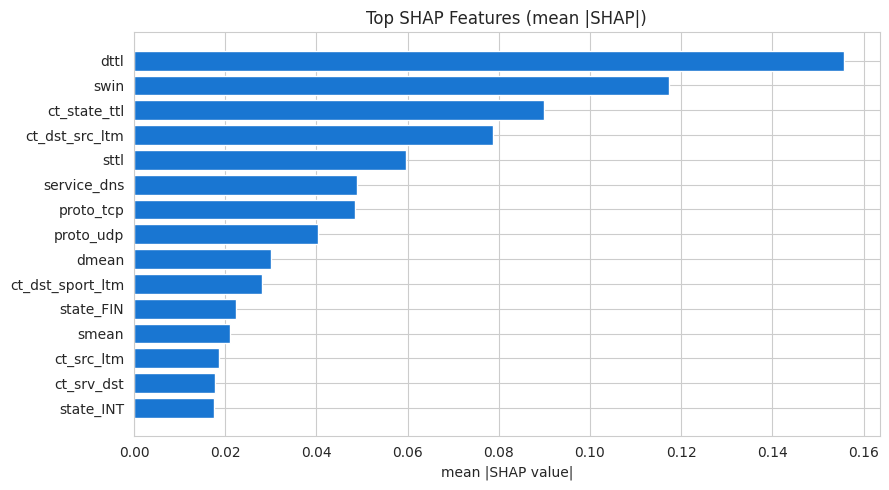

SHAP explanation time: 103.126s
SHAP summary plot:


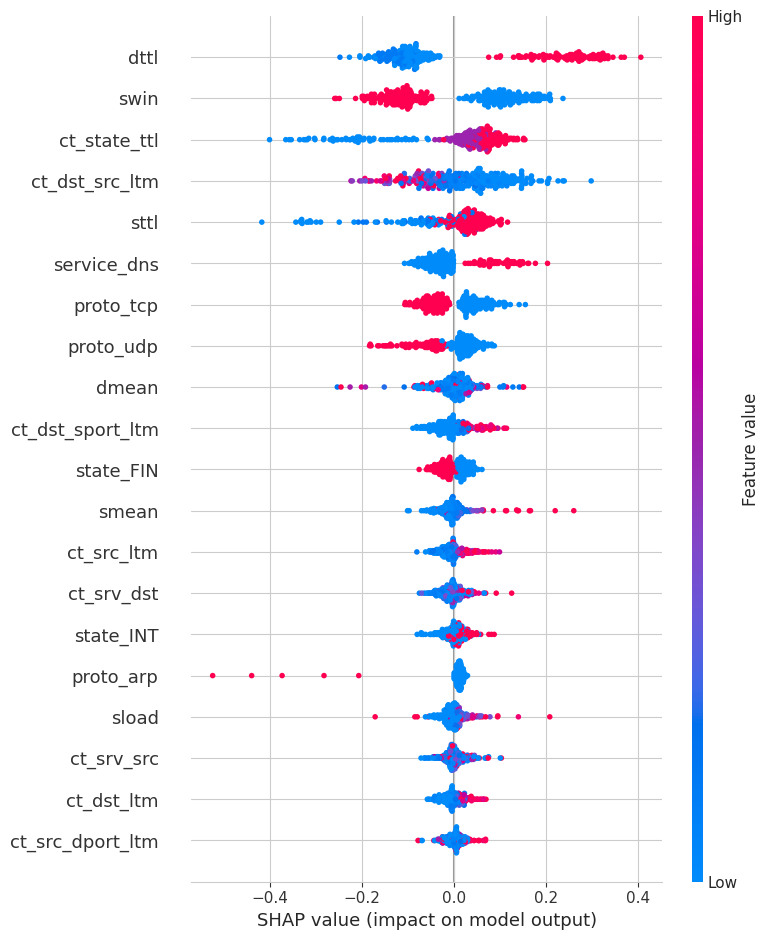

SHAP bar summary plot:


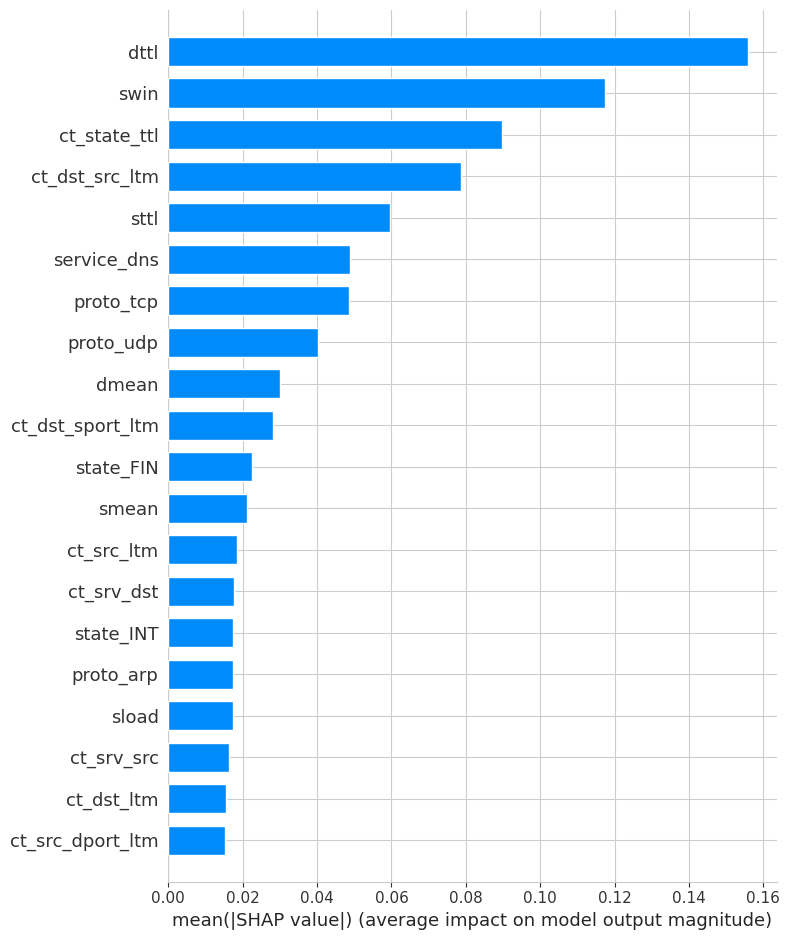

Local SHAP (predicted ATTACK) at sampled index 0


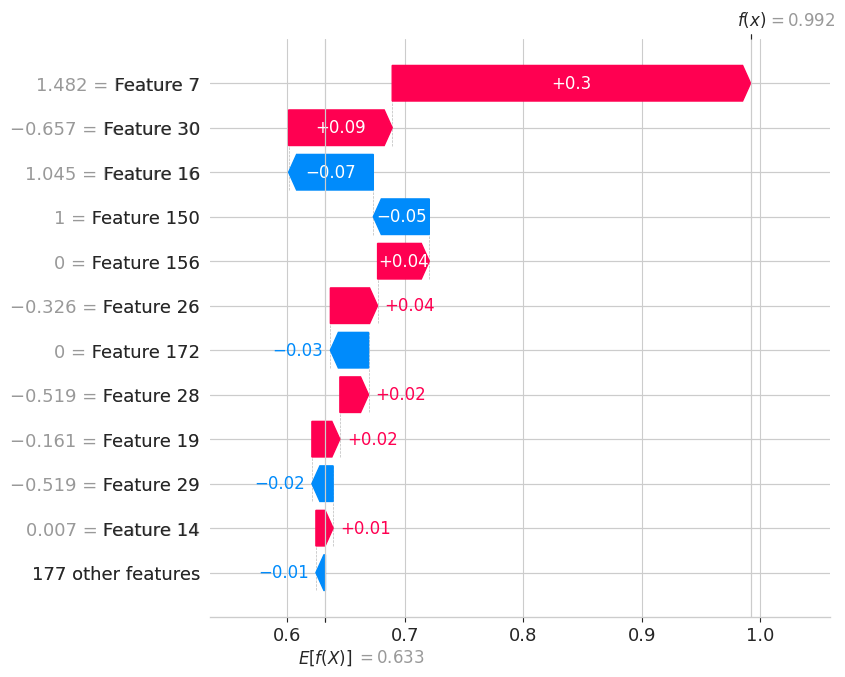

Local SHAP (predicted NORMAL) at sampled index 5


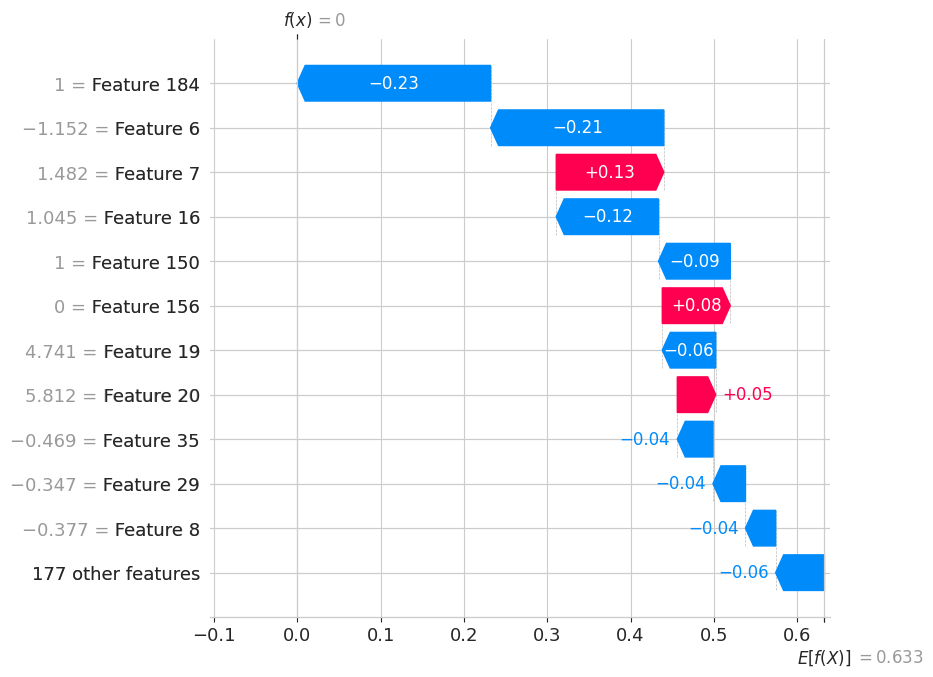

In [12]:
# STEP 2: SHAP global + local analysis and diagrams
# IMPORTANT: SHAP's background masker must match the model's input dimensionality exactly.
# We've seen cases where name lists (e.g. INFER_FEATURE_NAMES) match X_train.shape[1] but still
# disagree with model.n_features_in_ (e.g. 192 names vs 188 coefficients). That breaks LinearExplainer.

n_X = int(np.asarray(X_train).shape[1])
n_model = int(getattr(model, "n_features_in_", n_X))

if n_X != n_model:
    raise ValueError(
        f"Feature count mismatch: X_train has {n_X} columns but model.n_features_in_={n_model}. "
        f"Fix training data loading before running SHAP."
    )

feature_names = None

# Candidate name lists (only accept if they match the model input width)
_candidates = []

if "INFER_FEATURE_NAMES" in globals() and INFER_FEATURE_NAMES is not None:
    _c = [str(x) for x in list(INFER_FEATURE_NAMES)]
    if len(_c) == n_model:
        _candidates.append(("INFER_FEATURE_NAMES", _c))

if hasattr(model, "feature_names_in_") and getattr(model, "feature_names_in_", None) is not None:
    _c = [str(x) for x in list(model.feature_names_in_)]
    if len(_c) == n_model:
        _candidates.append(("model.feature_names_in_", _c))

# Optional: splits metadata (only if it matches model width)
try:
    cwd = Path.cwd()
    if (cwd / "splits").exists():
        _base = cwd
    elif (cwd.parent / "splits").exists():
        _base = cwd.parent
    elif len(cwd.parents) > 1 and (cwd.parents[1] / "splits").exists():
        _base = cwd.parents[1]
    else:
        _base = cwd

    _split_dir = _base / "splits" / "UNSW-NB15"

    _fn_path = _split_dir / "feature_names.csv"
    if _fn_path.exists():
        _loaded = pd.read_csv(_fn_path, header=None).squeeze().tolist()
        _c = [str(x) for x in _loaded]
        if len(_c) == n_model:
            _candidates.append(("splits/UNSW-NB15/feature_names.csv", _c))

    _pp_path = _split_dir / "preprocessor.pkl"
    _xraw_path = _split_dir / "X_train.csv"
    if _pp_path.exists() and _xraw_path.exists():
        _pp = joblib.load(_pp_path)
        _raw_cols = pd.read_csv(_xraw_path, nrows=1).columns.tolist()
        try:
            _derived = _pp.get_feature_names_out(_raw_cols).tolist()
        except Exception:
            _derived = _pp.get_feature_names_out().tolist()
        _c = [str(x) for x in _derived]
        if len(_c) == n_model:
            _candidates.append(("preprocessor.get_feature_names_out(...)", _c))
except Exception:
    pass

if _candidates:
    _src, feature_names = _candidates[0]
    if len(_candidates) > 1:
        # Prefer the first stable source; warn if multiple disagree
        for _src2, _names2 in _candidates[1:]:
            if _names2 != feature_names:
                print(
                    f"WARNING: multiple {n_model}-length feature name sources disagree "
                    f"({_src} vs {_src2}). Using {_src}."
                )
                break
else:
    feature_names = [f"f{i:03d}" for i in range(n_model)]
    print(
        f"WARNING: could not find any feature name list with length == model.n_features_in_={n_model}. "
        f"Falling back to generic names {feature_names[0]}..{feature_names[-1]}."
    )

X_train_arr = np.asarray(X_train)
X_test_arr = np.asarray(X_test)

X_train_df = pd.DataFrame(X_train_arr, columns=feature_names)
X_test_df = pd.DataFrame(X_test_arr, columns=feature_names)

bg_size = min(300, X_train_arr.shape[0])
sample_size = min(300, X_test_arr.shape[0])

rng = np.random.default_rng(42)
bg_idx = rng.choice(X_train_arr.shape[0], size=bg_size, replace=False)
sample_idx = rng.choice(X_test_arr.shape[0], size=sample_size, replace=False)

bg_X = X_train_arr[bg_idx]
X_sample_X = X_test_arr[sample_idx]

def _predict_attack_prob(data):
    p = model.predict_proba(data)
    if p.ndim == 2 and p.shape[1] > 1:
        return p[:, 1]
    return np.ravel(p)

t0 = time.time()
try:
    # Works for many sklearn estimators.
    explainer = shap.Explainer(model, bg_X)
    try:
        shap_exp = explainer(X_sample_X, check_additivity=False)
    except TypeError:
        shap_exp = explainer(X_sample_X)
except TypeError:
    # MLPClassifier is not always accepted directly by SHAP in this configuration,
    # so explain the class-1 probability instead.
    explainer = shap.Explainer(_predict_attack_prob, bg_X)
    shap_exp = explainer(X_sample_X)
shap_time = round(time.time() - t0, 3)

sv = np.asarray(shap_exp.values)

# Normalize SHAP outputs for binary classifiers (handles occasional extra output dims)
if sv.ndim == 3:
    if sv.shape[-1] == 2:
        sv = sv[..., 1]
    elif sv.shape[-1] == 1:
        sv = sv[..., 0]
elif sv.ndim > 3:
    raise ValueError(f"Unexpected SHAP values shape: {sv.shape}")

if sv.ndim != 2 or sv.shape[1] != n_model:
    raise ValueError(
        f"SHAP values shape {getattr(sv, 'shape', None)} does not match model.n_features_in_={n_model}."
    )

mean_abs_shap = np.abs(sv).mean(axis=0)
shap_top_idx = np.argsort(mean_abs_shap)[::-1][:15]
shap_top_features = [feature_names[i] for i in shap_top_idx]

shap_table = pd.DataFrame({"feature": shap_top_features, "mean_abs_shap": mean_abs_shap[shap_top_idx]})
print("Top SHAP features:")
print(shap_table.to_string(index=False))

plt.figure(figsize=(9, 5))
plt.barh(shap_table["feature"][::-1], shap_table["mean_abs_shap"][::-1], color="#1976d2")
plt.title("Top SHAP Features (mean |SHAP|)")
plt.xlabel("mean |SHAP value|")
plt.tight_layout()
plt.show()

print(f"SHAP explanation time: {shap_time}s")
print("SHAP summary plot:")
shap.summary_plot(sv, X_sample_X, feature_names=feature_names, show=True)

print("SHAP bar summary plot:")
shap.summary_plot(sv, X_sample_X, feature_names=feature_names, plot_type="bar", show=True)

# Local explanation for one attack and one normal sample
X_sample_df = pd.DataFrame(X_sample_X, columns=feature_names)
y_pred_sample = model.predict(X_sample_df)
attack_idx = np.where(y_pred_sample == 1)[0]
normal_idx = np.where(y_pred_sample == 0)[0]

def _select_single_output_explanation(exp_obj, sample_i, positive_class_index=1):
    vals = np.asarray(exp_obj.values)
    if vals.ndim == 2:
        return exp_obj[sample_i]
    if vals.ndim == 3:
        n_outputs = vals.shape[-1]
        class_i = positive_class_index if n_outputs > positive_class_index else 0
        return exp_obj[sample_i, :, class_i]
    raise ValueError(f"Unsupported SHAP explanation shape for waterfall: {vals.shape}")

if len(attack_idx) > 0:
    i = int(attack_idx[0])
    print(f"Local SHAP (predicted ATTACK) at sampled index {i}")
    shap.plots.waterfall(_select_single_output_explanation(shap_exp, i), max_display=12)

if len(normal_idx) > 0:
    j = int(normal_idx[0])
    print(f"Local SHAP (predicted NORMAL) at sampled index {j}")
    shap.plots.waterfall(_select_single_output_explanation(shap_exp, j), max_display=12)

# Persist for later cells
XAI_CTX = {
    "feature_names": feature_names,
    "X_train_df": X_train_df,
    "X_test_df": X_test_df,
    "X_sample": X_sample_df,
    "shap_exp": shap_exp,
    "shap_values": sv,
    "shap_top_features": shap_top_features,
    "shap_time_sec": shap_time,
}


Top candidate SHAP-informed rules:
                    rule  coverage  precision_attack  support
           sttl > 0.7219  0.000103          1.000000        4
 ct_dst_src_ltm > 0.1534  0.231145          0.925006     8934
    service_dns > 0.0000  0.270032          0.845070    10437
   ct_state_ttl > 0.6851  0.027891          0.228200     1078
  ct_state_ttl < -0.3263  0.225143          0.015858     8702
          sttl < -1.1516  0.236604          0.007545     9145
           dttl > 1.4816  0.000000          0.000000        0
          dttl < -0.7524  0.000000          0.000000        0
           swin > 1.0452  0.000000          0.000000        0
          swin < -0.9568  0.000000          0.000000        0
ct_dst_src_ltm < -0.6573  0.000000          0.000000        0
    service_dns < 0.0000  0.000000          0.000000        0


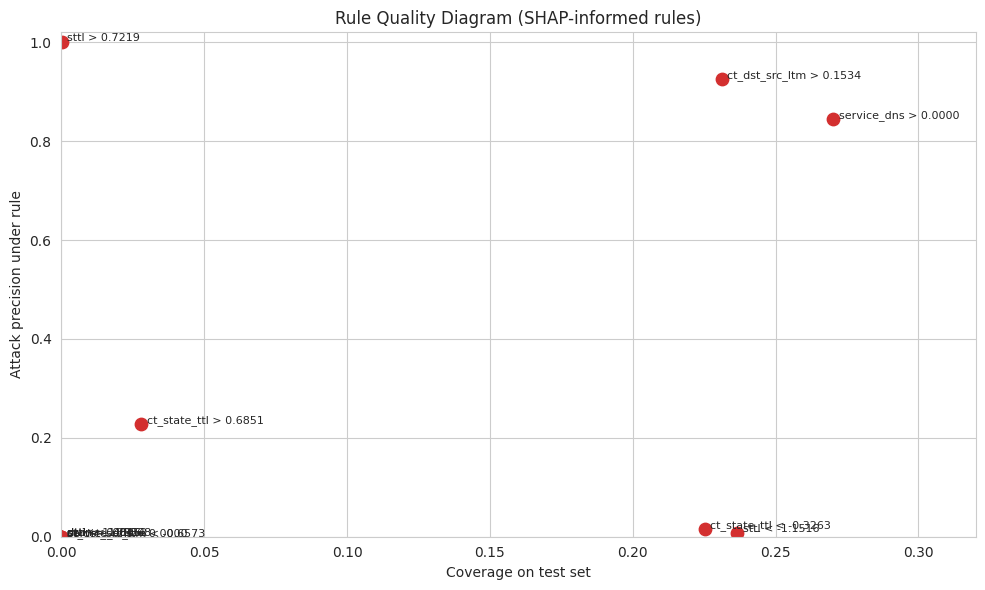


Best rule summary:
  rule: sttl > 0.7219
  coverage: 0.00010349020723913999
  precision_attack: 1.0
  support: 4


In [13]:
# STEP 3: SHAP-based manual rule drafting + rule diagrams
if 'XAI_CTX' not in globals():
    raise RuntimeError('Run STEP 2 first.')

X_test_df = XAI_CTX['X_test_df']
feature_names = XAI_CTX['feature_names']
shap_values = XAI_CTX['shap_values']
X_sample = XAI_CTX['X_sample']

# Build candidate thresholds from top SHAP features using sampled quantiles.
mean_abs = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs)[::-1][:6]

def eval_rule(mask, y_true):
    coverage = float(mask.mean())
    if mask.sum() == 0:
        return {'coverage': 0.0, 'precision_attack': 0.0, 'support': 0}
    precision_attack = float((y_true[mask] == 1).mean())
    return {
        'coverage': coverage,
        'precision_attack': precision_attack,
        'support': int(mask.sum())
    }

rule_rows = []
y_test_arr = np.asarray(y_test)

for i in top_idx:
    f = feature_names[i]
    q75 = float(X_sample[f].quantile(0.75))
    q25 = float(X_sample[f].quantile(0.25))

    mask_hi = X_test_df[f].values > q75
    mask_lo = X_test_df[f].values < q25

    hi_m = eval_rule(mask_hi, y_test_arr)
    lo_m = eval_rule(mask_lo, y_test_arr)

    rule_rows.append({'rule': f'{f} > {q75:.4f}', **hi_m})
    rule_rows.append({'rule': f'{f} < {q25:.4f}', **lo_m})

rule_df = pd.DataFrame(rule_rows).sort_values(['precision_attack', 'coverage'], ascending=False)
print('Top candidate SHAP-informed rules:')
print(rule_df.head(12).to_string(index=False))

# Plot rule quality diagram (precision vs coverage)
plot_df = rule_df.head(12).copy()
plt.figure(figsize=(10, 6))
plt.scatter(plot_df['coverage'], plot_df['precision_attack'], s=80, c='#d32f2f')
for _, r in plot_df.iterrows():
    plt.text(r['coverage'] + 0.002, r['precision_attack'] + 0.002, r['rule'][:28], fontsize=8)
plt.title('Rule Quality Diagram (SHAP-informed rules)')
plt.xlabel('Coverage on test set')
plt.ylabel('Attack precision under rule')
plt.xlim(0, min(1.0, max(0.05, plot_df['coverage'].max() + 0.05)))
plt.ylim(0, 1.02)
plt.tight_layout()
plt.show()

# Best single rule summary
best_rule = plot_df.iloc[0].to_dict() if len(plot_df) else None
if best_rule:
    print('\nBest rule summary:')
    for k, v in best_rule.items():
        print(f'  {k}: {v}')

XAI_CTX['rule_df'] = rule_df


SHAP analysis metrics:
                      metric      value
               shap_time_sec 103.126000
    sparsity_top10_mass_mean   0.731408
     fidelity_mae_top10_mask   0.101532
       stability_cosine_mean   0.840297
faithfulness_prob_drop_top10  -0.147685


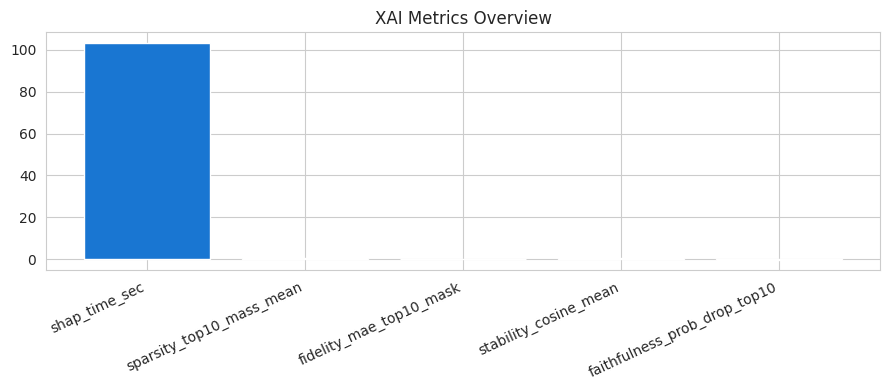

In [14]:
# STEP 4: SHAP analysis metrics (fidelity, stability, sparsity, faithfulness, time)
if 'XAI_CTX' not in globals():
    raise RuntimeError('Run STEP 2 first.')

X_sample = XAI_CTX['X_sample']
shap_values = XAI_CTX['shap_values']
feature_names = XAI_CTX['feature_names']

# Sparsity: concentration of contribution mass in top features
abs_sv = np.abs(shap_values)
frac_top10 = np.sum(np.sort(abs_sv, axis=1)[:, -10:], axis=1) / (np.sum(abs_sv, axis=1) + 1e-12)
sparsity_top10_mean = float(np.mean(frac_top10))

# Fidelity: compare model probability change after masking non-top features
proba_full = model.predict_proba(X_sample)[:, 1]
topk = 10
masked = np.zeros_like(X_sample.values)
for r in range(X_sample.shape[0]):
    idx = np.argsort(abs_sv[r])[::-1][:topk]
    masked[r, idx] = X_sample.values[r, idx]
proba_masked = model.predict_proba(masked)[:, 1]
fidelity_mae = float(np.mean(np.abs(proba_full - proba_masked)))

# Stability: SHAP similarity for neighboring samples
sub_n = min(300, X_sample.shape[0])
sub_idx = np.random.choice(X_sample.shape[0], size=sub_n, replace=False)
X_sub = X_sample.iloc[sub_idx].reset_index(drop=True)
sv_sub = shap_values[sub_idx]

dists = np.linalg.norm(X_sub.values[:, None, :] - X_sub.values[None, :, :], axis=2)
np.fill_diagonal(dists, np.inf)
nn = np.argmin(dists, axis=1)

cos_sims = []
for i in range(sub_n):
    a = sv_sub[i]
    b = sv_sub[nn[i]]
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-12
    cos_sims.append(float(np.dot(a, b) / denom))
stability_cos_mean = float(np.mean(cos_sims))

# Faithfulness: remove top-k SHAP features and measure probability drop
ablated = X_sample.values.copy()
for r in range(X_sample.shape[0]):
    idx = np.argsort(abs_sv[r])[::-1][:topk]
    ablated[r, idx] = 0.0
proba_ablated = model.predict_proba(ablated)[:, 1]
faithfulness_drop = float(np.mean(proba_full - proba_ablated))

metrics_df = pd.DataFrame([
    {'metric': 'shap_time_sec', 'value': XAI_CTX.get('shap_time_sec', np.nan)},
    {'metric': 'sparsity_top10_mass_mean', 'value': sparsity_top10_mean},
    {'metric': 'fidelity_mae_top10_mask', 'value': fidelity_mae},
    {'metric': 'stability_cosine_mean', 'value': stability_cos_mean},
    {'metric': 'faithfulness_prob_drop_top10', 'value': faithfulness_drop},
])

print('SHAP analysis metrics:')
print(metrics_df.to_string(index=False))

plt.figure(figsize=(9, 4))
plt.bar(metrics_df['metric'], metrics_df['value'], color=['#1976d2', '#43a047', '#fb8c00', '#8e24aa', '#e53935'])
plt.xticks(rotation=25, ha='right')
plt.title('XAI Metrics Overview')
plt.tight_layout()
plt.show()

XAI_CTX['metrics_df'] = metrics_df



LIME explanation (attack_like) at sampled index 0:
              rule   weight
 proto_nvp <= 0.00 0.475469
proto_narp <= 0.00 0.418323
proto_visa <= 0.00 0.392146
 proto_pup <= 0.00 0.310409
 proto_uti <= 0.00 0.310372
proto_aris <= 0.00 0.309960
proto_pnni <= 0.00 0.306539
proto_tlsp <= 0.00 0.304937
 proto_rdp <= 0.00 0.295800
proto_scps <= 0.00 0.293469
 proto_ggp <= 0.00 0.292058
proto_iatp <= 0.00 0.199720


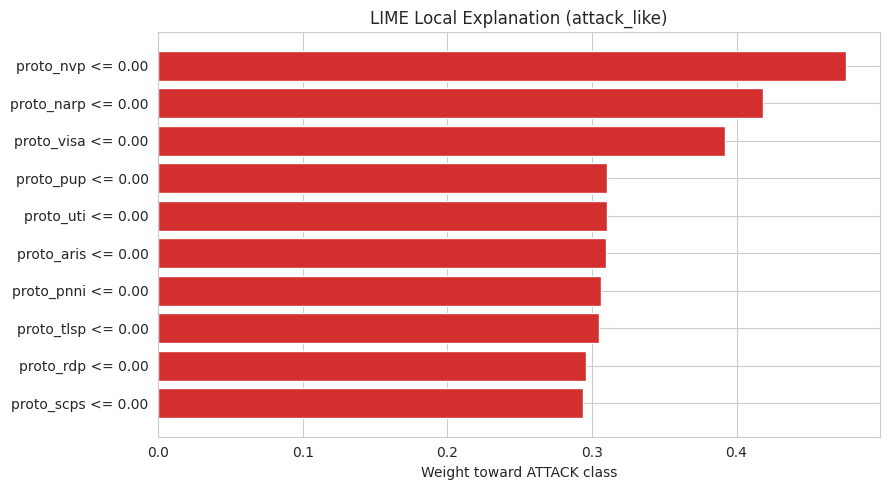


LIME explanation (normal_like) at sampled index 5:
                rule    weight
   proto_pgm <= 0.00  0.412144
   proto_dcn <= 0.00  0.345951
  proto_gmtp <= 0.00  0.305411
   proto_egp <= 0.00  0.305411
service_snmp <= 0.00  0.301238
 proto_swipe <= 0.00  0.297146
  proto_ipip <= 0.00  0.297066
   proto_pvp <= 0.00  0.282111
   proto_rvd <= 0.00  0.270185
   proto_tcf <= 0.00  0.204474
   proto_ddp <= 0.00 -0.163058
  proto_micp <= 0.00 -0.218151


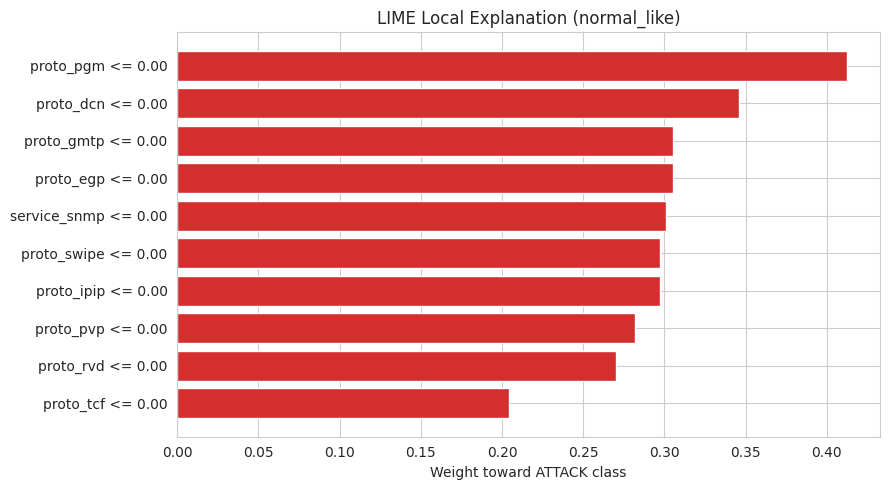


Aggregated LIME rule importance (mean |weight| across explained samples):
              rule  abs_weight
 proto_nvp <= 0.00    0.475469
proto_narp <= 0.00    0.418323
 proto_pgm <= 0.00    0.412144
proto_visa <= 0.00    0.392146
 proto_dcn <= 0.00    0.345951
 proto_pup <= 0.00    0.310409
 proto_uti <= 0.00    0.310372
proto_aris <= 0.00    0.309960
proto_pnni <= 0.00    0.306539
proto_gmtp <= 0.00    0.305411
 proto_egp <= 0.00    0.305411
proto_tlsp <= 0.00    0.304937


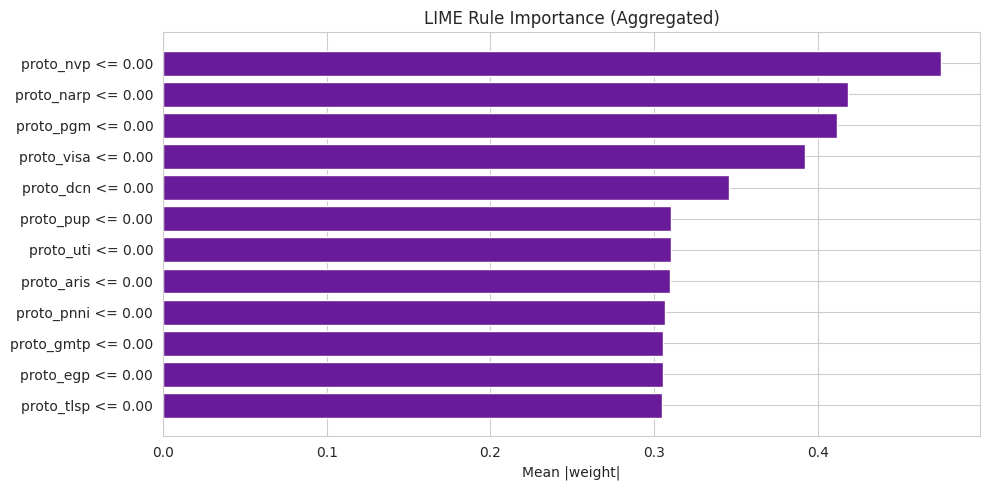

In [15]:
# STEP 5: LIME local explanations + diagrams
if 'XAI_CTX' not in globals():
    raise RuntimeError('Run STEP 2 first.')

X_train_df = XAI_CTX['X_train_df']
X_sample = XAI_CTX['X_sample']
feature_names = XAI_CTX['feature_names']

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_df.values,
    feature_names=feature_names,
    class_names=['normal', 'attack'],
    mode='classification',
    discretize_continuous=True,
    random_state=42
)

# Explain one predicted attack and one predicted normal sample.
preds = model.predict(X_sample)
attack_ix = np.where(preds == 1)[0]
normal_ix = np.where(preds == 0)[0]
chosen = []
if len(attack_ix) > 0:
    chosen.append(('attack_like', int(attack_ix[0])))
if len(normal_ix) > 0:
    chosen.append(('normal_like', int(normal_ix[0])))
if not chosen:
    chosen.append(('fallback', 0))

lime_rows = []
for tag, idx in chosen:
    exp = lime_explainer.explain_instance(
        X_sample.iloc[idx].values,
        model.predict_proba,
        num_features=12
    )
    pairs = exp.as_list(label=1)

    local_df = pd.DataFrame(pairs, columns=['rule', 'weight']).sort_values('weight', ascending=False)
    print(f'\nLIME explanation ({tag}) at sampled index {idx}:')
    print(local_df.to_string(index=False))

    plt.figure(figsize=(9, 5))
    plot_df = local_df.head(10).iloc[::-1]
    colors = ['#d32f2f' if w > 0 else '#1976d2' for w in plot_df['weight']]
    plt.barh(plot_df['rule'], plot_df['weight'], color=colors)
    plt.title(f'LIME Local Explanation ({tag})')
    plt.xlabel('Weight toward ATTACK class')
    plt.tight_layout()
    plt.show()

    for r, w in pairs:
        lime_rows.append({'sample_tag': tag, 'rule': r, 'weight': float(w)})

lime_df = pd.DataFrame(lime_rows)
agg_lime = (lime_df.assign(abs_weight=lambda d: d['weight'].abs())
                  .groupby('rule', as_index=False)['abs_weight']
                  .mean()
                  .sort_values('abs_weight', ascending=False)
                  .head(12))

print('\nAggregated LIME rule importance (mean |weight| across explained samples):')
print(agg_lime.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.barh(agg_lime['rule'][::-1], agg_lime['abs_weight'][::-1], color='#6a1b9a')
plt.title('LIME Rule Importance (Aggregated)')
plt.xlabel('Mean |weight|')
plt.tight_layout()
plt.show()

XAI_CTX['lime_df'] = lime_df


In [16]:
# STEP 6: Final XAI summary table
if 'XAI_CTX' not in globals():
    raise RuntimeError('Run STEP 2 first.')

metrics_df = XAI_CTX.get('metrics_df', pd.DataFrame(columns=['metric', 'value']))
rule_df = XAI_CTX.get('rule_df', pd.DataFrame())
lime_df = XAI_CTX.get('lime_df', pd.DataFrame())

best_rule = None
if len(rule_df) > 0:
    best_rule = rule_df.sort_values(['precision_attack', 'coverage'], ascending=False).iloc[0]

summary_rows = [
    {'item': 'model', 'value': MODEL_NAME if 'MODEL_NAME' in globals() else 'MLP'},
    {'item': 'dataset', 'value': 'UNSW-NB15'},
    {'item': 'xai_samples_shap', 'value': len(XAI_CTX.get('X_sample', []))},
    {'item': 'shap_top_feature_1', 'value': (XAI_CTX.get('shap_top_features') or ['NA'])[0]},
    {'item': 'lime_rules_collected', 'value': int(len(lime_df))},
]

if best_rule is not None:
    summary_rows.extend([
        {'item': 'best_rule', 'value': best_rule['rule']},
        {'item': 'best_rule_precision_attack', 'value': round(float(best_rule['precision_attack']), 6)},
        {'item': 'best_rule_coverage', 'value': round(float(best_rule['coverage']), 6)},
    ])

for _, r in metrics_df.iterrows():
    summary_rows.append({'item': r['metric'], 'value': round(float(r['value']), 6)})

xai_summary = pd.DataFrame(summary_rows)
print('Final XAI summary:')
print(xai_summary.to_string(index=False))

# Optional save for reporting
xai_summary.to_csv(f"{RESULT_DIR}//{ARTIFACT_NAME}_xai_summary.csv", index=False)
print(f'\nSaved: {RESULT_DIR}//{ARTIFACT_NAME}_xai_summary.csv')


Final XAI summary:
                        item         value
                       model           MLP
                     dataset     UNSW-NB15
            xai_samples_shap           300
          shap_top_feature_1          dttl
        lime_rules_collected            24
                   best_rule sttl > 0.7219
  best_rule_precision_attack           1.0
          best_rule_coverage      0.000103
               shap_time_sec       103.126
    sparsity_top10_mass_mean      0.731408
     fidelity_mae_top10_mask      0.101532
       stability_cosine_mean      0.840297
faithfulness_prob_drop_top10     -0.147685

Saved: /content/drive/MyDrive/MLmodeling/XAI/results/UNSW-NB15//UNSW_13_MLP_xai_summary.csv
